# Tutorial for ROI-based colocalization analysis in napari

This tutorial demonstrates how the `napari-colocalization` plugin
can be used to analyse the spatial colocalization of two channels.

We will cover
1. **Loading** an example image of a two-channel image
2. **Threshold** the signal and turn it into **regions of interest
   (ROIs)** as a napari *Labels* layer.
3. Open the **Colocalization Analysis** widget, choose metrics, and
   **Run** the analysis per ROI.
4. Read the results table and density plot to interpret the results.

We will not cover
- Pitfalls of colocalization analysis. See https://imagej.net/imaging/colocalization-analysis for a great description instead.
- Descriptions of the available metrics. Again, see this tutorial https://imagej.net/imaging/colocalization-analysis#pixel-intensity-based for a description of methods available. Not each metric is useful for each scenario, so this is a must read. Other pitfalls are also discussed here: https://imagej.net/plugins/coloc-2#pitfalls-of-the-manders-and-costes-methods

## Setup

Install the plugin with napari and a Qt backend:

In [1]:
# Install the plugin and its dependencies
%pip install -q "napari-colocalization[all]"

Note: you may need to restart the kernel to use updated packages.


In [1]:
import napari
import numpy as np
import pandas as pd
from scipy.ndimage import median_filter

# Launch napari viewer
viewer = napari.Viewer()

## 1. Open napari and load the sample image

After opening napari, open the sample image with **File → Open Sample → Colocalization → Confocal red/green dyes**. 

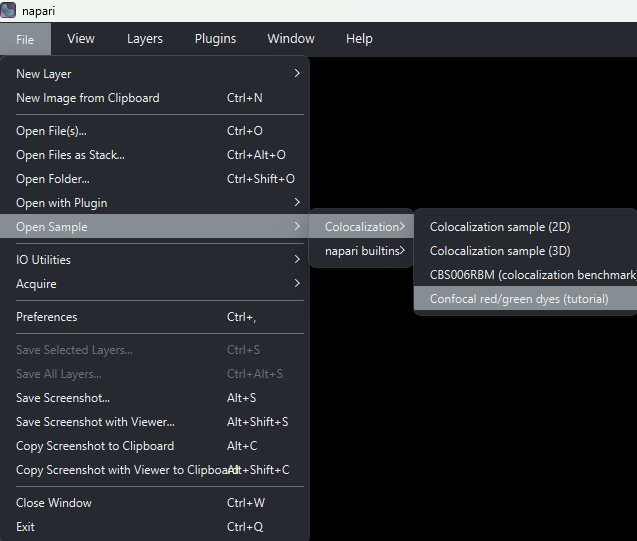

This adds two image layers, `coloc_red` and `coloc_green`, which represent two proteins that are part of a dimer. 

The parts of the image that contain both proteins will be shown as yellow.

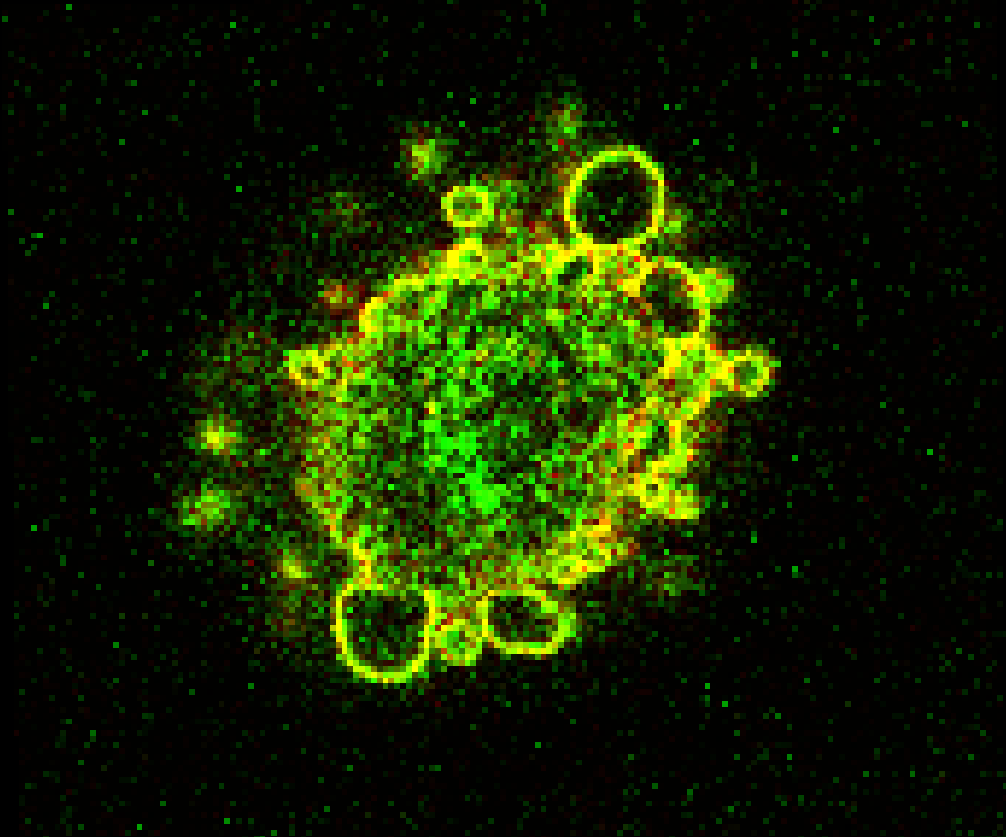
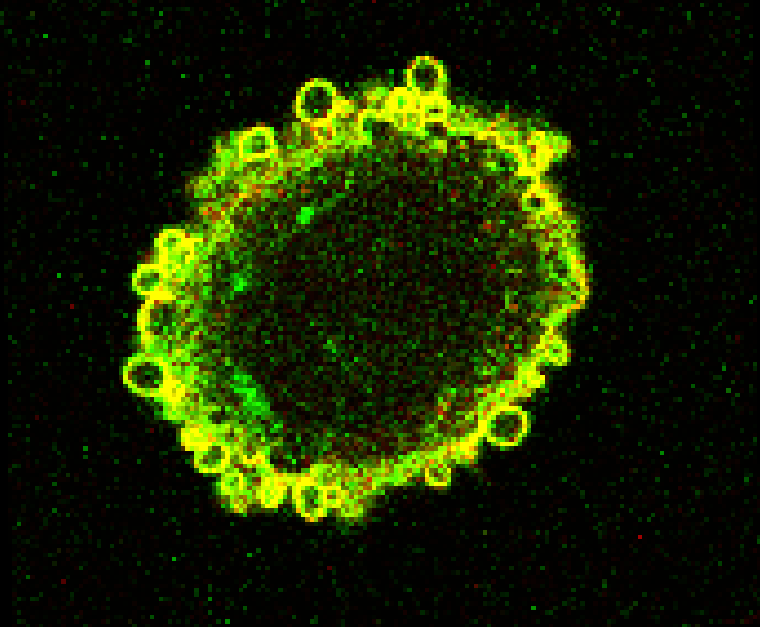

The image is quite noisy, so we will apply a small median filter here to remove salt and pepper noise.

In [2]:
# run median filter per slice with a radius of 2 pixels
viewer.layers['coloc_green'].data = median_filter(viewer.layers['coloc_green'].data, size=3)
viewer.layers['coloc_red'].data = median_filter(viewer.layers['coloc_red'].data, size=3)

This does change our pixel intensities and should be applied with care. You can see it makes the image blurrier:
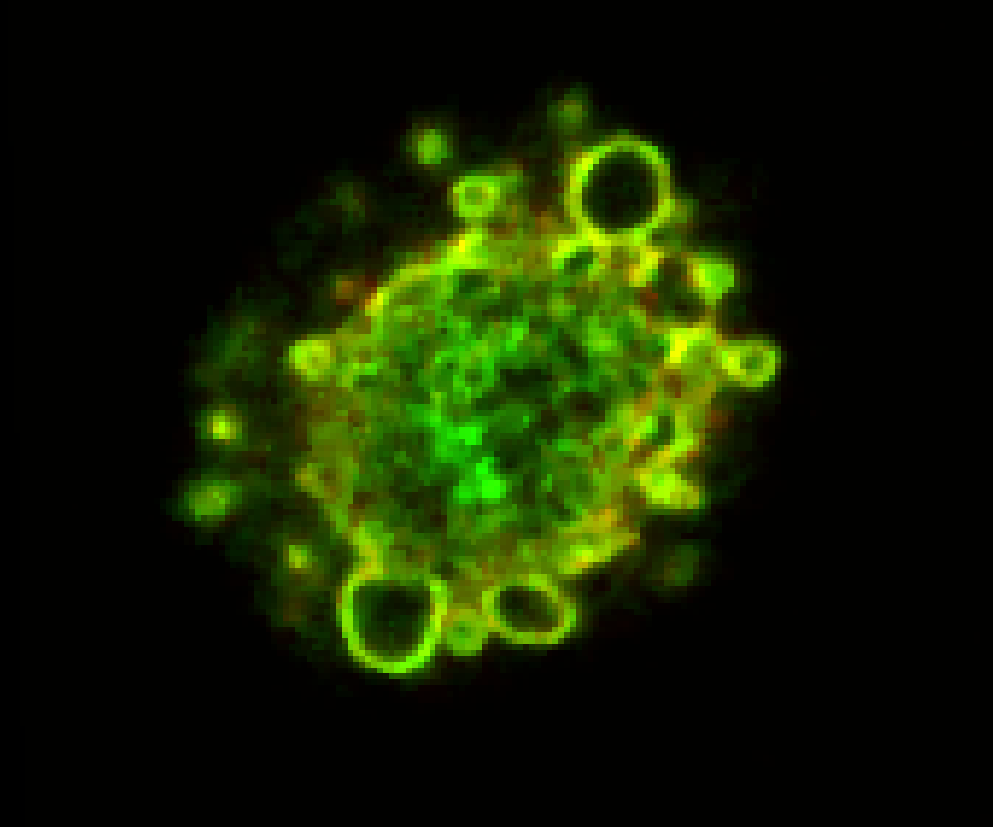

# 2. Run first analysis
To get a quick idea of what the colocalization plugin can do, open it with **Plugins → Colocalization Analysis**. Then, select the options as in the image, enabling all correlation metrics, and click "Run".

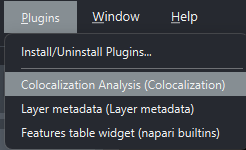

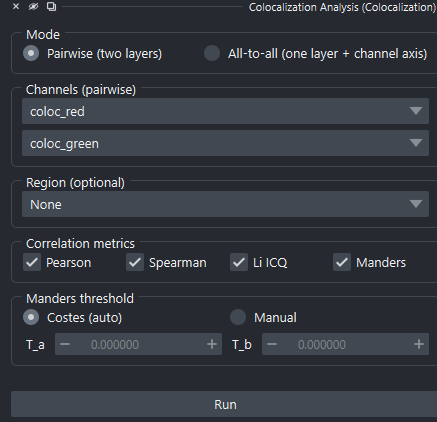

We see a high correlation of pixel intensities, with a Pearson correlation of 0.88. However, the plot below shows that most pixels have a low intensity, suggesting that we have a lot of background that is included in the analysis.

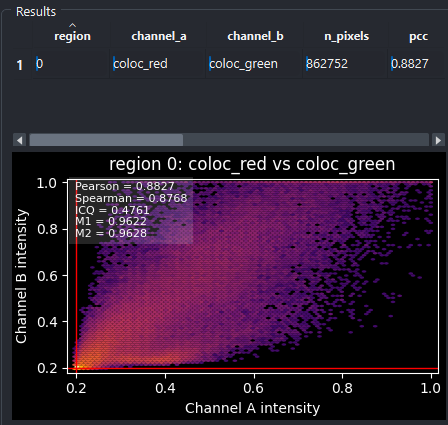
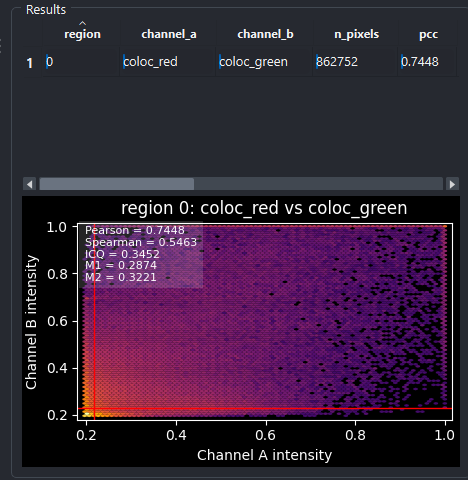

## 3. Analyze colocalization in ROI

Both channels contain spurious background fluorescence. We wish to perform thresholding before we analyze colocalization, so as not to bias our analysis. To this aim, here we pick an arbitrary threshold of 0.3 and keep only pixels above the threshold. In other settings, you may perform segmentation in other ways, but a discussion of this is beyond the scope of this tutorial.

The resulting mask will be displayed in a way that will show only foreground pixels, with all background pixels blacked out.

This is the scripted equivalent of painting regions in a napari **Labels**
layer (or drawing rectangles in a **Shapes** layer). The widget reads
either kind of layer as its *Region* input.

In [3]:
red = viewer.layers['coloc_red'].data
green = viewer.layers['coloc_green'].data

threshold = 0.3

# Create a foreground mask by thresholding each channel, keep pixels that are
# foreground for at least one of the channels.
foreground = (red > threshold) | (green > threshold)

# create color map for visualisation
cmap = napari.utils.DirectLabelColormap(
    color_dict={
        0: [0, 0, 0, 1],     # background -> opaque black
        1: [1, 1, 1, 1],     # foreground -> transparent
        None: [0, 0, 0, 1],  # fallback for any other value
    }
)
viewer.add_labels(foreground, name='foreground', colormap=cmap, blending="multiplicative")

<Labels layer 'foreground' at 0x2be9df7a120>

We can now rerun the analysis with slightly changed settings: for "Region" we wish to select the "foreground" layer. Also note that, when Manders is enabled, the **Costes auto-threshold** is used to threshold signal. However, we have already thresholded the image, so we select "Manual" and 0 for T_a and T_b.

Once we have selected these settings, we hit "Run" again.

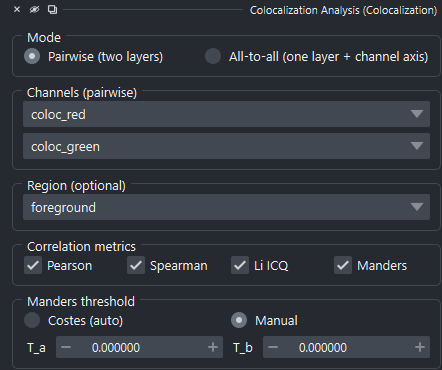

The result shows a smaller, but more realistic estimate of colocalisation. Still, the Pearson correlation is near 0.7, suggesting that the two proteins indeed do colocalize.

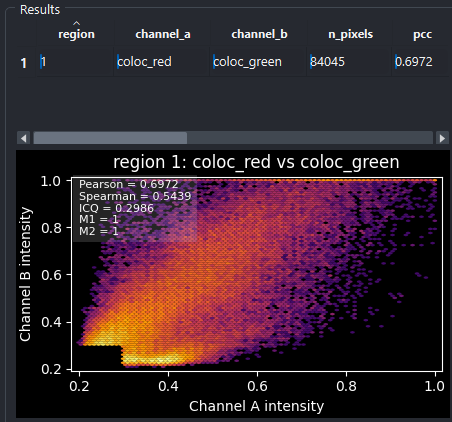

## Summary

- Colocalization is only meaningful on real signal — threshold (or draw
  ROIs) before quoting a number.
- A **Labels** or **Shapes** layer becomes the widget's *Region* input,
  giving one result row per ROI (here we used ROI to distinguish back- and foreground).
- The plugin computes Pearson, Spearman, Li ICQ and Manders (with Costes
  auto-thresholds), and exports the table and density plots if desired.